# The LLAMA of WallStreet: LLM data extraction and sentiment analysis 

**Read carefully the following instructions and suggestions before writing code.**

## Task description and suggestions

You work as Data Scientist in a company that develops algorithmic trading strategies. 
Your supervisor aims to develop a sentiment analysis pipeline for Reddit posts, with the objective of incorporating Reddit comments into an automated trading strategy.  
The goal is to leverage the content of these comments to extract actionable insights for identifying potential stock buying or selling opportunities. 

In particular, he wants a dataset with the `ticker` (or stock symbol: AAPL for Apple, TSLA for Tesla etc...) of the company and the general `sentiment`  towards that stock.

Moreover, he wants to be able to analyze comments every day using Leonardo and `SLURM`, **BUT**, unfortunately, he does not know how to write or execute code.
He only wants to send prompt in natural english.


The pipeline you are going to create does not have any particular constraint about the technologies to be used; however, here are **some important suggestions**:

1. The **number of comments to be processed is big**, we are talking about 100k comments. So, it is **strongly advised to parallelize your workflow in some way** (i.e. multitrheading or other options)... the choice is yours.

2. Alternatevely, you can analyze just a smaller subset of the dataframe, again, the choice is yours.

3. The data extraction task (i.e. verifying a comment is about companies and identifying a ticker associated to the comment) can be done leveraging "LLM knowledge". In the section "Data extraction example" you can find an example of how to use an LLM for data extraction.

4. Once you have identified the relevant comments and associated them with their respective stock tickers, the sentiment analysis task can be carried out using either a large language model (LLM) or a domain-specific pre-trained model (e.g. [cardiffnlp/twitter-roberta-base-sentiment-latest](https://huggingface.co/cardiffnlp/twitter-roberta-base-sentiment-latest)) or any other sentiment analysis model. 
The choice is yours; however, keep in mind that if you plan to run the sentiment analysis on worker nodes, the model must be downloaded and made available on those nodes in advance.

5. Write down, in a Markdown cell, the architecture/plan/structure/technology you would use to convert this workflow into an agentic system that can send the `student_job_LLM.py` SLURM script to the Leonardo cluster and run the analysis above. Imagine that this would become a tool for data scientists in an organization: they would interact with chatbots, but sometimes ask for this analysis to be run on Leonardo and then receive the results. The idea is to reason about how this could become chatbot functionality implemented as an agent plus a certain number of tools. **HINT**: remember the example shown during Lesson 7 [`1_agent_applications_the_slurmjob_maker.ipynb`](../../lecture_8/notebooks/1_agent_applications_the_slurmjob_maker.ipynb).

6. Given the layout you described in point 5, the tools you defined, and the responsibilities of the agentic system, write the system prompt for this system.

7. **OPTIONAL**: actually write the agentic system. Implement it in this notebook, using the LLM we provide, and show that it prepares SLURM jobs that would launch `student_job_LLM.py` on Leonardo, get job status, and optionally fetch the results locally. **HINT**: remember the example shown during Lesson 7 [`1_agent_applications_the_slurmjob_maker.ipynb`](../../lecture_8/notebooks/1_agent_applications_the_slurmjob_maker.ipynb).


**Given the large number of comments, it may be helpful to use this notebook as a playground to test the pipeline on a small subset first. Once you've implemented and verified your logic here, you can move it to a .py script and run it as a non-interactive job. For a template, see the `student_job_LLM.py` and `config/LLM_start_job.job` scripts. That said, feel free to organize your code in whatever way works best for you.**

Note that in this notebook we limited the number of comments to be processed to 1000. Change the variable LIMIT if you want to make tests with more comments in this notebook.  

# Imports

In [16]:
from datetime import datetime
from enum import Enum
from typing import Optional
import time, os
import socket
import subprocess
import urllib.request
from concurrent.futures import ThreadPoolExecutor, as_completed

import pandas as pd
import requests
import matplotlib.pyplot as plt
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI

import warnings
warnings.filterwarnings("ignore")

# General config

The following general configuration dir sets the LLM that you may use in your project.  

In [17]:
print(socket.gethostname())

lrdn0022.leonardo.local


In [18]:
t0 = datetime.now()
print(f"Execution started: {t0}")

INPUT_FILE = "reddit_comments.csv"
MODEL_NAME = "mistralai/Mistral-Small-3.2-24B-Instruct-2506"

VLLM_ENDPOINT = "http://lrdn2874:8000/v1" # Change this for every new leonardo session
API_KEY = "password"

# OpenAI client pointing to the shared model server
llm = ChatOpenAI(base_url=VLLM_ENDPOINT, api_key=API_KEY, model=MODEL_NAME, request_timeout=30)

Execution started: 2026-06-18 15:56:24.715468


## Environment setup and connection check

In [19]:
# Confirm the kernel runs on a Leonardo worker node and the model server responds
print("Running on node:", socket.gethostname())
print("llm endpoint:", llm.openai_api_base)

headers = {"Authorization": f"Bearer {API_KEY}"}
r = requests.get(f"{VLLM_ENDPOINT}/models", headers=headers)
print("Model served:", r.json()["data"][0]["id"])

Running on node: lrdn0022.leonardo.local
llm endpoint: http://lrdn2874:8000/v1
Model served: mistralai/Mistral-Small-3.2-24B-Instruct-2506


# Data extraction example

LLMs can be effectively used to solve data extraction tasks. For instance, consider a collection of legal documents where laws are cited in inconsistent formats. You can provide an LLM with a system prompt that includes examples of how laws are typically cited and instruct it to extract all legal citations from the text using a standardized response format. This approach enables the model to recognize and structure heterogeneous references in a consistent way.

Response format is specified as a Python class which extends a pydantic BaseModel class. This is all you need to know, don't worry you don't need to study pydantic...  
Below you can find an example.  

In [20]:
# Using structured outputes to constraint the answer to have a specific format

SYSTEM_PROMPT = """You are an helpful assistant trained to extract Laws citations from legal proceedings.
You will be given a sentence, your task is to extract citations using the following format: [{"article": "<article_no>", "code":"<law_collection>"}].

- <article_no> is a string containing the number of the cited article
- <law_collection> is the name of the code containing the cited law. Law collection can assume only 3 possible values: United States Code, Code of Federal Regulations, NA if the name of the document is not present or the input text does not contain any citation.

Here are some examples:

[INPUT]: Tomorrow I have an exam about USC art. 1
[OUTPUT]: [{"article": "1", "code": "United States Code"}]
[INPUT]: I like pizza!
[OUTPUT]: [{"article":"NA", "code": "NA"}]
[INPUT]: I found article 22 of the United States Code very clear. On the opposite, the art 13 of CFR is totally incomprensible.
[OUTPUT]: [{"article": "22", "code": "United States Code"}, {"article": "13", "code": "Code of Federal Regulations"}]
"""


class Codes(Enum):
    USC = "United States Code"
    CFR = "Code of Federal Regulations"
    NA = "NA"


class Citation(BaseModel):
    article: str
    code: Codes


class Citations(BaseModel):
    citations: list[Citation]


answ = llm.with_structured_output(Citations).invoke(
    input=[
        {"role": "system", "content": SYSTEM_PROMPT},
        {
            "role": "user",
            "content": "Did you study article 33 of the USC and article 3475-bis of USC?",
        },
    ],
    temperature=0,
)

answ

Citations(citations=[Citation(article='33', code=<Codes.USC: 'United States Code'>), Citation(article='3475-bis', code=<Codes.USC: 'United States Code'>)])

Then you can acces values by iterating over the elements of the list. The output of the llm invocation is a standard python object!

**If you get a connection error running the above cell, it's because the model is still being loaded. In this case you must wait a bit and try again...**

In [21]:
for citation in answ.citations:
    print(f"Article: {citation.article}\nCode: {citation.code.value}\n\n")

Article: 33
Code: United States Code


Article: 3475-bis
Code: United States Code




# Read data

In [22]:
df = pd.read_csv(INPUT_FILE)
print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101974 entries, 0 to 101973
Data columns (total 4 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   datetime       101974 non-null  object
 1   subreddits     101974 non-null  object
 2   submission_id  101974 non-null  object
 3   comments       101974 non-null  object
dtypes: object(4)
memory usage: 3.1+ MB
None


,datetime,subreddits,submission_id,comments
0,2025-03-29 18:32:13,news,1jmrj8p,"A British man has been praised for tackling a suspected knifeman to the ground in central Amsterdam.\n\nThe tourist, who does not wish to be named, restrained the suspect after five people were stabbed near the Dutch capital’s Dam Square on Thursday.\n\nVideo of the incident shows the Briton, wearing jeans and a black hoodie, kneeling on his back and twisting his arm until police arrived.\n\nAmsterdam’s Mayor Femke Halsema said she was impressed by his decisive action, telling local broadcasters he showed “exceptional” instinct."
1,2025-03-29 18:32:13,news,1jmrj8p,Glad they recognized him. He did a great thing.
2,2025-03-29 18:32:13,news,1jmrj8p,A news on a British tourist that doesn't involve embarrassing behavior?\n\nThis is eerie. Something is up and we should get ready.
3,2025-03-29 18:32:13,news,1jmrj8p,That guys needs some real love. Hopefully he Atleast gets a gofundme. Considering how much money is spent on antiterrorism then give him a few million atleast. We really need to reward the right people.
4,2025-03-29 18:32:13,news,1jmrj8p,"“I’m Millwall, mate”. Probably"


# Logical steps to follow

1. Extract one or more tickers from each comment. 

2. Associate a sentiment (very positive, positive, neutral, negative, very negative) to each comment. To perform this task you can use an LLM or a model trained specifically for this task;

3. Map sentiment to integers: 2, 1, 0, -1, -2; 

4. Once you have mapped sentiment to numbers, calculate a daily sentiment for each ticker; 

5. Calculate some metrics (e.g. min, max, average sentiment) for each ticker on a daily basis; 

6. Plot the sentiment trend for some tickers you find interesting (e.g. AAPL, META, etc.) 

# Test your pipeline here

Before processing, we check whether comments can be pre-filtered by subreddit to reduce the number of LLM calls. The dataset contains only two subreddits, news (101752) and technews (222), both general news sources rather than finance-specific ones. Subreddit-based filtering would therefore remove almost all data or none of it, so it is not a useful filter here. The relevance judgment (is this comment about a publicly traded company?) must instead be made by the LLM itself, comment by comment.

In [23]:
print(df["subreddits"].value_counts())

subreddits
news        101752
technews       222
Name: count, dtype: int64


In [24]:
pd.set_option("display.max_colwidth", None)
technews = df[df["subreddits"] == "technews"]
technews["comments"].head(20)

101752                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   It took them... a while
101753    I'm sure around here they'll use it for good stuff like:\n\n\- knowing when to close down a road to trim trees and impact the greatest number of people\n\n\- knowing when to close down a road to dig random holes and fill them back in and impact the greatest number of people\n\n\- where free parking still is to let you get downtown and slap hourly charges on them to discourage people from going downtown\n\n\- is traffic moving too fast?  wher

In [25]:
mask = df["comments"].str.contains(
    r"\b(Tesla|Apple|Google|Microsoft|Amazon|Nvidia|Meta|Boeing|Intel|AMD)\b",
    case=False, na=False, regex=True
)
print(f"Number of comments mentioning one of the companies: {mask.sum()}")
df[mask]["comments"].head(10)

Number of comments mentioning one of the companies: 1466


500                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     

### Observations from exploring the data

A simple keyword search for ten well-known companies (Tesla, Apple, Google, etc.) 
matches 1466 comments. However, inspecting these matches shows that a company name 
appearing in a comment does not mean the comment is about the company as a tradable 
stock. We observed several distinct cases:

- Company names inside URLs (e.g. google.com, podcasts.apple.com) that are not 
  references to the company at all.
- Companies mentioned in a political or personal context (e.g. Tesla discussed in 
  relation to Elon Musk and Putin) rather than as an investment.
- Companies referenced as products or by their customers (e.g. "Tesla drivers") 
  rather than the listed entity.

This confirms that ticker extraction cannot be done by keyword matching alone. The 
relevance judgment requires understanding context, which is why we use an LLM rather 
than a rule-based approach. The keyword search here is used only to locate candidate 
test cases, not as the extraction method itself.

In [26]:
class TickerExtraction(BaseModel):
    is_about_company: bool = Field(
        description="True if the comment discusses one or more publicly traded companies, False otherwise"
    )
    tickers: list[str] = Field(
        description="List of stock ticker symbols (e.g. AAPL, TSLA). Empty if no company is discussed."
    )

### Ticker extraction with an LLM

We use the structured-output pattern: a Pydantic schema defines the exact shape of 
the response, and the LLM is constrained to return an object matching it. Two design 
choices are worth noting:

1. The schema includes an explicit `is_about_company` boolean in addition to the 
   ticker list. Forcing the model to first decide whether the comment is about a 
   company makes it less likely to invent tickers for irrelevant comments.

2. The system prompt uses few-shot examples chosen to match the failure cases we 
   found while exploring the data: company names in URLs, companies mentioned via 
   their customers ("Tesla drivers"), companies as products ("Apple laptop"), and 
   unrelated comments. Showing the model these specific edge cases teaches it where 
   the boundary lies.

Unlike the law-citation example, we cannot use an Enum to constrain the output, since 
there are thousands of possible tickers. The ticker field is therefore a free string 
list, which trades guaranteed validity for flexibility.

In [27]:
TICKER_SYSTEM_PROMPT = """You are a financial analyst assistant. You will be given a single Reddit comment.
Your task is to identify any publicly traded companies the comment expresses an opinion or discussion about, and return their stock ticker symbols.

Rules:
- Only return a ticker if the comment is genuinely about the company as a business or stock.
- Convert company names to their stock ticker (e.g. Apple to AAPL, Tesla to TSLA, Nvidia to NVDA).
- Do NOT return a ticker if the company name only appears inside a URL (e.g. google.com, apple.com).
- Do NOT return a ticker if the company is only mentioned as a product or in passing with no relevance to the business (e.g. "my Apple laptop").
- If the comment is not about any publicly traded company, return is_about_company = false and an empty list.

Here are some examples:

[COMMENT]: NVDA is going to keep climbing after these earnings, I'm holding.
[OUTPUT]: is_about_company = true, tickers = ["NVDA"]

[COMMENT]: I'm long on Apple but shorting Intel this quarter.
[OUTPUT]: is_about_company = true, tickers = ["AAPL", "INTC"]

[COMMENT]: Check this article: https://www.google.com/article/12345
[OUTPUT]: is_about_company = false, tickers = []

[COMMENT]: How does this make you Tesla drivers feel?
[OUTPUT]: is_about_company = false, tickers = []

[COMMENT]: I just bought a new Apple laptop and it's great.
[OUTPUT]: is_about_company = false, tickers = []

[COMMENT]: Minority Report much? This is dystopian.
[OUTPUT]: is_about_company = false, tickers = []
"""

In [28]:
def extract_tickers(comment: str, temperature: float = 0) -> TickerExtraction:
    result = llm.with_structured_output(TickerExtraction).invoke(
        input=[
            {"role": "system", "content": TICKER_SYSTEM_PROMPT},
            {"role": "user", "content": comment},
        ],
        temperature=0,
    )
    return result

In [29]:
sample = df.head(20).copy()

results = []
for comment in sample["comments"]:
    extraction = extract_tickers(comment)
    results.append(extraction.tickers)

sample["tickers"] = results
sample[["subreddits", "comments", "tickers"]]


,subreddits,comments,tickers
0,news,"A British man has been praised for tackling a suspected knifeman to the ground in central Amsterdam.\n\nThe tourist, who does not wish to be named, restrained the suspect after five people were stabbed near the Dutch capital’s Dam Square on Thursday.\n\nVideo of the incident shows the Briton, wearing jeans and a black hoodie, kneeling on his back and twisting his arm until police arrived.\n\nAmsterdam’s Mayor Femke Halsema said she was impressed by his decisive action, telling local broadcasters he showed “exceptional” instinct.",[]
1,news,Glad they recognized him. He did a great thing.,[]
2,news,A news on a British tourist that doesn't involve embarrassing behavior?\n\nThis is eerie. Something is up and we should get ready.,[]
3,news,That guys needs some real love. Hopefully he Atleast gets a gofundme. Considering how much money is spent on antiterrorism then give him a few million atleast. We really need to reward the right people.,[]
4,news,"“I’m Millwall, mate”. Probably",[]
5,news,Good job River Cartwright.,[]
6,news,He should receive a medal. This kind of bravery should be rewarded,[]
7,news,What? No good guy with a gun was involved? How can this be possible?,[]
8,news,"The bravery shown by the British tourist in Amsterdam is truly remarkable. In a tense and dangerous situation, he didn’t hesitate to act when a knife attack occurred in a busy public space. Tackling the suspect to the ground and restraining him until the police arrived was an incredibly courageous and quick-thinking move. It's easy to imagine how panic could set in during such an attack, but this individual’s instincts and actions helped prevent what could have been a much worse scenario.\n\nWhat stands out here is not only the tourist’s bravery but his humility in staying anonymous despite the praise he received. In a world where heroes often seek recognition, it's refreshing to see someone act purely out of selflessness and a desire to help. The acknowledgment from Amsterdam’s Mayor, calling his actions ""exceptional,"" speaks volumes about the positive impact one individual can have in an unpredictable and dangerous situation.",[]
9,news,"I have read that knife crime is a problem in Europe, but that's the thing -- you can beat down someone with a knife. AR-15, not so easy, but that's the price we pay for freedom in the USA I guess. We just have to accept kids being shot from time to time",[]


### Evaluating the extractor on real data

Running the extractor on the first 20 comments shows mostly correct behavior. 18 of 20 
comments correctly returned an empty list, including comments that mention tempting 
tokens like "NASA" and "US" but are not about any company.

One failure class appeared: the comment "Sounds like Mars needs some Freedom" returned 
[FDX]. This is a false positive. The model appears to have stretched the word "Freedom" 
into a loosely associated ticker, even though the comment is a joke about Mars and has 
nothing to do with a traded company.

This illustrates a real weakness: the model can over-reach for tickers based on single 
words that resemble or associate with company names. We address it in two ways. First, 
we add an explicit rule telling the model not to guess tickers from isolated words. 
Second, we add a few-shot example showing this exact failure case mapped to an empty 
result. This is an example of iterating on the prompt based on observed errors rather 
than assumptions.

In [30]:
TICKER_SYSTEM_PROMPT_V2 = TICKER_SYSTEM_PROMPT.replace(
    "- If the comment is not about any publicly traded company,",
    "- Only return a ticker if you are confident it corresponds to a specific company actually being discussed. Never guess a ticker from an isolated word or loose association.\n- If the comment is not about any publicly traded company,"
) + """
[COMMENT]: Sounds like Mars needs some Freedom and democracy
[OUTPUT]: is_about_company = false, tickers = []
"""

In [31]:
def extract_tickers_with_prompt(comment: str, system_prompt: str, temperature: float = 0) -> TickerExtraction:
    return llm.with_structured_output(TickerExtraction).invoke(
        input=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": comment},
        ],
        temperature=0,
    )

In [32]:
sample["tickers_v2"] = [extract_tickers_with_prompt(c, TICKER_SYSTEM_PROMPT_V2).tickers for c in sample["comments"]]
sample[["comments", "tickers", "tickers_v2"]]

,comments,tickers,tickers_v2
0,"A British man has been praised for tackling a suspected knifeman to the ground in central Amsterdam.\n\nThe tourist, who does not wish to be named, restrained the suspect after five people were stabbed near the Dutch capital’s Dam Square on Thursday.\n\nVideo of the incident shows the Briton, wearing jeans and a black hoodie, kneeling on his back and twisting his arm until police arrived.\n\nAmsterdam’s Mayor Femke Halsema said she was impressed by his decisive action, telling local broadcasters he showed “exceptional” instinct.",[],[]
1,Glad they recognized him. He did a great thing.,[],[]
2,A news on a British tourist that doesn't involve embarrassing behavior?\n\nThis is eerie. Something is up and we should get ready.,[],[]
3,That guys needs some real love. Hopefully he Atleast gets a gofundme. Considering how much money is spent on antiterrorism then give him a few million atleast. We really need to reward the right people.,[],[]
4,"“I’m Millwall, mate”. Probably",[],[]
5,Good job River Cartwright.,[],[]
6,He should receive a medal. This kind of bravery should be rewarded,[],[]
7,What? No good guy with a gun was involved? How can this be possible?,[],[]
8,"The bravery shown by the British tourist in Amsterdam is truly remarkable. In a tense and dangerous situation, he didn’t hesitate to act when a knife attack occurred in a busy public space. Tackling the suspect to the ground and restraining him until the police arrived was an incredibly courageous and quick-thinking move. It's easy to imagine how panic could set in during such an attack, but this individual’s instincts and actions helped prevent what could have been a much worse scenario.\n\nWhat stands out here is not only the tourist’s bravery but his humility in staying anonymous despite the praise he received. In a world where heroes often seek recognition, it's refreshing to see someone act purely out of selflessness and a desire to help. The acknowledgment from Amsterdam’s Mayor, calling his actions ""exceptional,"" speaks volumes about the positive impact one individual can have in an unpredictable and dangerous situation.",[],[]
9,"I have read that knife crime is a problem in Europe, but that's the thing -- you can beat down someone with a knife. AR-15, not so easy, but that's the price we pay for freedom in the USA I guess. We just have to accept kids being shot from time to time",[],[]


### Testing on company-related comments

So far the extractor has mostly been tested on the first 20 comments, which happen to 
be unrelated to companies, so the value of those tests was mainly confirming that the 
extractor correctly returns nothing. To evaluate it where companies are actually 
present, we now run it on 20 comments that mention a well-known company, reusing the 
keyword search from the data-exploration step.

This is a harder test. As we saw earlier, a company name appearing in a comment does 
not mean the comment is about the company as a stock. We expect three kinds of 
outcomes: correct ticker extraction when a company is genuinely discussed, correct 
empty results when the name appears in a URL or an unrelated context (for example 
Tesla mentioned in a political discussion about Elon Musk), and borderline cases where 
the right answer is debatable.

In [33]:
# Comments that mention at least one well-known company (from our earlier keyword search)
company_comments = df[mask].head(20).copy()

company_comments["tickers"] = [
    extract_tickers_with_prompt(c, TICKER_SYSTEM_PROMPT_V2).tickers
    for c in company_comments["comments"]
]

company_comments[["comments", "tickers"]]

,comments,tickers
500,The Onion gets meta. A sign of the times.,[]
794,"You'll forgive me if my sympathy coverage ran out for police about the time I was shown the bodycam video of half a dozen cops firing 47 shots at a man who's family had called 911 to try to help because he was suicidal. Miraculously, he survived 9 gunshot wounds later, but this was my turning point and hearing his mother scream after they shot him was one of the most chilling things I've ever heard. By the way they cuffed her on the scene, for I dunno, existing. Anyway here's the article link for anybody that wants to be even more pissed off.\n\nhttps://www.google.com/amp/s/www.live5news.com/2023/05/10/south-carolina-man-sues-police-after-being-shot-47-times-during-mental-crisis/%3foutputType=amp",[]
837,I will always jump on a chance to link people to the episodes of Knowledge Fight where they played/covered the Alex Jones [Depositions](https://podcasts.apple.com/us/podcast/knowledge-fight/id1192992870?i=1000434021952). They are wild and you get to see everything laid bare and inspected. Great listen if you’ve the time or just want to see him squirm and trip over his own dick. Later episodes have his dad and employees deposed.\n\n[Ep.1](https://podcasts.apple.com/us/podcast/knowledge-fight/id1192992870?i=1000434021952)\n\n[Ep.2](https://podcasts.apple.com/us/podcast/knowledge-fight/id1192992870?i=1000459733820)\n\n[Ep.3](https://podcasts.apple.com/us/podcast/knowledge-fight/id1192992870?i=1000466246199)\n\n[Ep.4](https://podcasts.apple.com/us/podcast/knowledge-fight/id1192992870?i=1000549027542)\n\n[Ep.5](https://podcasts.apple.com/us/podcast/knowledge-fight/id1192992870?i=1000555672789)\n\n[Ep.6](https://podcasts.apple.com/us/podcast/knowledge-fight/id1192992870?i=1000555909671)\n\n[Ep.7](https://podcasts.apple.com/us/podcast/knowledge-fight/id1192992870?i=1000563698036)\n\n[Ep.8](https://podcasts.apple.com/us/podcast/knowledge-fight/id1192992870?i=1000583387452)\n\n[Ep.9](https://podcasts.apple.com/us/podcast/knowledge-fight/id1192992870?i=1000584457221)\n\n[Ep.10](https://podcasts.apple.com/us/podcast/knowledge-fight/id1192992870?i=1000585592643)\n\n[Ep.11](https://podcasts.apple.com/us/podcast/knowledge-fight/id1192992870?i=1000587207791)\n\n[Ep.12](https://podcasts.apple.com/us/podcast/knowledge-fight/id1192992870?i=1000589166755)\n\n[Ep.13](https://podcasts.apple.com/us/podcast/knowledge-fight/id1192992870?i=1000593080962)\n\n[Ep.14](https://podcasts.apple.com/us/podcast/knowledge-fight/id1192992870?i=1000595121930)\n\n[Ep.15](https://podcasts.apple.com/us/podcast/knowledge-fight/id1192992870?i=1000596849820),[]
853,"Good, fuck this guy. Also, consider donating to Sandy Hook Promise. It’s a nonprofit created by Sandy Hook parents to combat gun violence. [Sandy Hook Promise](https://takeaction.sandyhookpromise.org/a/texasresponse?source=a_google_d2dtexasresponse2022_p-br&ms=a_google_d2dtexasresponse2022_p-br&amtOpts=26,50,100,260,500,1000&utm_source=google&utm_medium=cpc&utm_campaign=d2dtexasresponse2022&gclid=EAIaIQobChMI_p74ps7AhgMV61lHAR1wbAGYEAAYASAAEgKTMfD_BwE)",[]
1317,">The implications of a secret channel of communication between Musk and Putin are enormous for western security. The Tesla tycoon is a key player in the US space programme and has a high-level security clearance. His company SpaceX launches US national security satellites, his Starlink satellite communications system is critical to the war in Ukraine, and he runs one of the world’s biggest and most influential social media platforms, X, which has provided a vehicle for Russian disinformation campaigns\n\nA sensible government would be looking to nationalize SpaceX and Starlink ASAP.",[TSLA]
1318,">The implications of a secret channel of communication between Musk and Putin are enormous for western security. The Tesla tycoon is a key player in the US space programme and has a high-level security clearance. His company SpaceX launches US national security satellites, his Starlink 

### Results on company-related comments

The extractor performs well on the clear cases: company names inside URLs are correctly 
ignored, and most Amazon-related comments are correctly tagged AMZN. The comment "How 
does this make you Tesla drivers feel?" correctly returns nothing.

The harder cases raise one genuine design question and two separate issues.

The design question is where to draw the boundary of a comment being "about" a company. 
Several comments discuss Elon Musk, Putin or SpaceX while mentioning "Tesla" only in 
passing, and these were tagged TSLA. Whether that is correct depends on interpretation:

- A narrow interpretation tags a ticker only when the company itself is the direct 
  subject of discussion as a business or investment. This gives a cleaner signal but 
  misses indirectly relevant news.
- A broad interpretation tags a ticker whenever the comment carries information that 
  could plausibly move the stock, such as news about a CEO's legal exposure. This 
  captures more signal but adds noise and makes the boundary fuzzier.

Rather than assert one interpretation, we implement both as separate prompts and 
compare them on the same comments in the next section. This turns the design decision 
into something we can observe rather than argue about.

Two further issues are worth noting independently of this choice:

1. Outdated tickers. One comment was tagged TWTR, but Twitter was delisted in 2022 and 
is no longer publicly traded. The model has a knowledge cutoff and does not know which 
tickers are currently valid. A production pipeline would validate extracted tickers 
against a list of currently listed symbols.

2. The "about a company" ambiguity also appears in sentiment-bearing comments. A 
comment criticising Amazon working conditions carries sentiment about Amazon but is not 
investment discussion. Whether to tag it depends on the downstream goal, and the 
narrow-versus-broad comparison below speaks directly to this.

These points are acceptable given the assignment's emphasis on understanding over 
perfect accuracy, and the comparison that follows is our way of investigating the main 
one rather than guessing.

In [34]:
TICKER_PROMPT_BROAD = TICKER_SYSTEM_PROMPT_V2  # the version we already have

TICKER_PROMPT_NARROW = TICKER_SYSTEM_PROMPT_V2.replace(
    "- Only return a ticker if the comment is genuinely about the company as a business or stock.",
    "- Only return a ticker if the company itself is the direct subject of discussion as a business or investment. Do NOT return a ticker when the company is mentioned only because a related person, product, or event is being discussed (for example a CEO's politics, or a subsidiary), even if it might indirectly affect the stock."
)

print("NARROW differs from BROAD:", TICKER_PROMPT_NARROW != TICKER_PROMPT_BROAD)

NARROW differs from BROAD: True


In [35]:
comparison = df[mask].head(20).copy()

comparison["narrow"] = [extract_tickers_with_prompt(c, TICKER_PROMPT_NARROW).tickers for c in comparison["comments"]]
comparison["broad"]  = [extract_tickers_with_prompt(c, TICKER_PROMPT_BROAD).tickers for c in comparison["comments"]]

comparison[["comments", "narrow", "broad"]]

,comments,narrow,broad
500,The Onion gets meta. A sign of the times.,[],[]
794,"You'll forgive me if my sympathy coverage ran out for police about the time I was shown the bodycam video of half a dozen cops firing 47 shots at a man who's family had called 911 to try to help because he was suicidal. Miraculously, he survived 9 gunshot wounds later, but this was my turning point and hearing his mother scream after they shot him was one of the most chilling things I've ever heard. By the way they cuffed her on the scene, for I dunno, existing. Anyway here's the article link for anybody that wants to be even more pissed off.\n\nhttps://www.google.com/amp/s/www.live5news.com/2023/05/10/south-carolina-man-sues-police-after-being-shot-47-times-during-mental-crisis/%3foutputType=amp",[],[]
837,I will always jump on a chance to link people to the episodes of Knowledge Fight where they played/covered the Alex Jones [Depositions](https://podcasts.apple.com/us/podcast/knowledge-fight/id1192992870?i=1000434021952). They are wild and you get to see everything laid bare and inspected. Great listen if you’ve the time or just want to see him squirm and trip over his own dick. Later episodes have his dad and employees deposed.\n\n[Ep.1](https://podcasts.apple.com/us/podcast/knowledge-fight/id1192992870?i=1000434021952)\n\n[Ep.2](https://podcasts.apple.com/us/podcast/knowledge-fight/id1192992870?i=1000459733820)\n\n[Ep.3](https://podcasts.apple.com/us/podcast/knowledge-fight/id1192992870?i=1000466246199)\n\n[Ep.4](https://podcasts.apple.com/us/podcast/knowledge-fight/id1192992870?i=1000549027542)\n\n[Ep.5](https://podcasts.apple.com/us/podcast/knowledge-fight/id1192992870?i=1000555672789)\n\n[Ep.6](https://podcasts.apple.com/us/podcast/knowledge-fight/id1192992870?i=1000555909671)\n\n[Ep.7](https://podcasts.apple.com/us/podcast/knowledge-fight/id1192992870?i=1000563698036)\n\n[Ep.8](https://podcasts.apple.com/us/podcast/knowledge-fight/id1192992870?i=1000583387452)\n\n[Ep.9](https://podcasts.apple.com/us/podcast/knowledge-fight/id1192992870?i=1000584457221)\n\n[Ep.10](https://podcasts.apple.com/us/podcast/knowledge-fight/id1192992870?i=1000585592643)\n\n[Ep.11](https://podcasts.apple.com/us/podcast/knowledge-fight/id1192992870?i=1000587207791)\n\n[Ep.12](https://podcasts.apple.com/us/podcast/knowledge-fight/id1192992870?i=1000589166755)\n\n[Ep.13](https://podcasts.apple.com/us/podcast/knowledge-fight/id1192992870?i=1000593080962)\n\n[Ep.14](https://podcasts.apple.com/us/podcast/knowledge-fight/id1192992870?i=1000595121930)\n\n[Ep.15](https://podcasts.apple.com/us/podcast/knowledge-fight/id1192992870?i=1000596849820),[],[]
853,"Good, fuck this guy. Also, consider donating to Sandy Hook Promise. It’s a nonprofit created by Sandy Hook parents to combat gun violence. [Sandy Hook Promise](https://takeaction.sandyhookpromise.org/a/texasresponse?source=a_google_d2dtexasresponse2022_p-br&ms=a_google_d2dtexasresponse2022_p-br&amtOpts=26,50,100,260,500,1000&utm_source=google&utm_medium=cpc&utm_campaign=d2dtexasresponse2022&gclid=EAIaIQobChMI_p74ps7AhgMV61lHAR1wbAGYEAAYASAAEgKTMfD_BwE)",[],[]
1317,">The implications of a secret channel of communication between Musk and Putin are enormous for western security. The Tesla tycoon is a key player in the US space programme and has a high-level security clearance. His company SpaceX launches US national security satellites, his Starlink satellite communications system is critical to the war in Ukraine, and he runs one of the world’s biggest and most influential social media platforms, X, which has provided a vehicle for Russian disinformation campaigns\n\nA sensible government would be looking to nationalize SpaceX and Starlink ASAP.","[SPCE, STLK]",[TSLA]
1318,">The implications of a secret channel of communication between Musk and Putin are enormous for western security. The Tesla tycoon is a key player in the US space programme and has a high-level security clearance. His company SpaceX launches US national se

### Narrow versus broad comparison

The two interpretations agree on the clear cases: Amazon and Google comments are tagged 
identically, and URLs and unrelated comments return nothing under both. The differences 
appear exactly where expected, in the borderline cases, and they are revealing:

- Comment 2031 (leaving Meta/Instagram): narrow returns nothing, broad returns META. 
  This is the design choice in its purest form. The broad reading treats users abandoning 
  the platform as a market-relevant signal; the narrow reading notes that Meta is not 
  the subject of the comment.

- Comments 1317 and 1318 (Musk, Putin, SpaceX): broad returns TSLA, but narrow returns 
  [SPCE, STLK]. This is an unexpected and instructive failure of the narrow prompt. By 
  focusing on the "direct subject", it tagged SpaceX and Starlink, which are private 
  companies with no public tickers. SPCE is in fact Virgin Galactic, not SpaceX, and 
  STLK is unrelated to Starlink. The model hallucinated tickers for non-traded entities. 
  The broad prompt avoided this by landing on TSLA, the one actually listed company 
  connected to Musk.

This is a genuine argument in favour of the broad interpretation: chasing the literal 
subject can pull the model toward entities that are not even publicly traded, producing 
worse tickers rather than cleaner ones. It also reinforces the separate need to validate 
extracted tickers against a list of currently listed symbols, since both prompts produced 
at least one invalid ticker (TWTR, SPCE, STLK).

## Validating extracted tickers

Across the previous tests the model produced several tickers that are not valid for our 
purpose. TWTR refers to Twitter, which was delisted in 2022 and is no longer publicly 
traded. SPCE and STLK were returned for a comment about SpaceX and Starlink, both of 
which are private companies with no public listing, and SPCE is in fact Virgin Galactic 
rather than SpaceX. The language model has a knowledge cutoff and no reliable view of 
which symbols are currently traded, so it can return tickers that are outdated, private, 
or simply hallucinated.

To address this we add a validation step. After extraction, each ticker is checked 
against a list of symbols that are actually listed on major US exchanges (NASDAQ and 
NYSE), and any ticker not on that list is discarded. This keeps the pipeline grounded in 
tradable instruments, which matters because the downstream goal is a trading signal.

We use a static symbol list loaded from a file rather than a live lookup. On an HPC 
cluster the compute nodes often have limited or no internet access, so a static list is 
more robust and fully reproducible. The trade-off is that the list can become stale over 
time and would need periodic refreshing in a production system.

In [36]:
try:
    urllib.request.urlopen("https://www.google.com", timeout=5)
    print("Internet access: YES")
except Exception as e:
    print(f"Internet access: NO ({e})")

Internet access: NO (<urlopen error [Errno 101] Network is unreachable>)


In [37]:
def load_valid_tickers(*paths) -> set:
    valid = set()
    for path in paths:
        with open(path) as f:
            for line in f:
                symbol = line.strip().upper()
                if symbol:
                    valid.add(symbol)
    return valid

VALID_TICKERS = load_valid_tickers(
    "../../hugo/nasdaqlisted.txt",
    "../../hugo/nyselisted.txt",
)

print(f"Loaded {len(VALID_TICKERS)} valid tickers")
print("TSLA valid?", "TSLA" in VALID_TICKERS)
print("TWTR valid?", "TWTR" in VALID_TICKERS)
print("SPCE valid?", "SPCE" in VALID_TICKERS)
print("STLK valid?", "STLK" in VALID_TICKERS)

Loaded 6497 valid tickers
TSLA valid? True
TWTR valid? False
SPCE valid? True
STLK valid? False


### Limits of list-based validation

Testing the validation set confirms it catches two of the three error types we saw: 
TWTR (delisted) and STLK (hallucinated) are both correctly rejected. However, SPCE is 
accepted as valid, which is correct in a narrow sense: SPCE is the real ticker for 
Virgin Galactic, a listed company. The problem in the original comment was that the 
model returned SPCE while meaning SpaceX. This highlights a limit of list-based 
validation: it can reject tickers that do not exist or are no longer traded, but it 
cannot detect a ticker that is valid yet refers to the wrong company. That kind of 
semantic error would require verifying that the company behind the ticker matches the 
one discussed, which is beyond a simple symbol list.

Because the list is a static snapshot committed to the repository, the validation is 
reproducible against a fixed set of symbols. A company that lists or delists after the 
snapshot date will not be reflected until the list is refreshed, which is the same kind 
of lag that affects the model's own knowledge.

A further subtlety is that ticker validity is time-dependent relative to the comment 
date, not just today's date. SpaceX is a good example: it was private when these 
comments were written but has since listed under the ticker SPCX. Even with an up to 
date list, validating against today's symbols would not make the original SPCE 
extraction correct, since the model returned the wrong ticker and the company was not 
traded when the comment was written. A rigorous pipeline would validate tickers against 
the set of symbols listed as of each comment's date.

In [38]:
def validate_tickers(tickers: list[str]) -> list[str]:
    return [t for t in tickers if t.upper() in VALID_TICKERS]

In [39]:
comparison["broad_validated"] = [validate_tickers(tickers) for tickers in comparison["broad"]]
comparison[["comments", "broad", "broad_validated"]]

,comments,broad,broad_validated
500,The Onion gets meta. A sign of the times.,[],[]
794,"You'll forgive me if my sympathy coverage ran out for police about the time I was shown the bodycam video of half a dozen cops firing 47 shots at a man who's family had called 911 to try to help because he was suicidal. Miraculously, he survived 9 gunshot wounds later, but this was my turning point and hearing his mother scream after they shot him was one of the most chilling things I've ever heard. By the way they cuffed her on the scene, for I dunno, existing. Anyway here's the article link for anybody that wants to be even more pissed off.\n\nhttps://www.google.com/amp/s/www.live5news.com/2023/05/10/south-carolina-man-sues-police-after-being-shot-47-times-during-mental-crisis/%3foutputType=amp",[],[]
837,I will always jump on a chance to link people to the episodes of Knowledge Fight where they played/covered the Alex Jones [Depositions](https://podcasts.apple.com/us/podcast/knowledge-fight/id1192992870?i=1000434021952). They are wild and you get to see everything laid bare and inspected. Great listen if you’ve the time or just want to see him squirm and trip over his own dick. Later episodes have his dad and employees deposed.\n\n[Ep.1](https://podcasts.apple.com/us/podcast/knowledge-fight/id1192992870?i=1000434021952)\n\n[Ep.2](https://podcasts.apple.com/us/podcast/knowledge-fight/id1192992870?i=1000459733820)\n\n[Ep.3](https://podcasts.apple.com/us/podcast/knowledge-fight/id1192992870?i=1000466246199)\n\n[Ep.4](https://podcasts.apple.com/us/podcast/knowledge-fight/id1192992870?i=1000549027542)\n\n[Ep.5](https://podcasts.apple.com/us/podcast/knowledge-fight/id1192992870?i=1000555672789)\n\n[Ep.6](https://podcasts.apple.com/us/podcast/knowledge-fight/id1192992870?i=1000555909671)\n\n[Ep.7](https://podcasts.apple.com/us/podcast/knowledge-fight/id1192992870?i=1000563698036)\n\n[Ep.8](https://podcasts.apple.com/us/podcast/knowledge-fight/id1192992870?i=1000583387452)\n\n[Ep.9](https://podcasts.apple.com/us/podcast/knowledge-fight/id1192992870?i=1000584457221)\n\n[Ep.10](https://podcasts.apple.com/us/podcast/knowledge-fight/id1192992870?i=1000585592643)\n\n[Ep.11](https://podcasts.apple.com/us/podcast/knowledge-fight/id1192992870?i=1000587207791)\n\n[Ep.12](https://podcasts.apple.com/us/podcast/knowledge-fight/id1192992870?i=1000589166755)\n\n[Ep.13](https://podcasts.apple.com/us/podcast/knowledge-fight/id1192992870?i=1000593080962)\n\n[Ep.14](https://podcasts.apple.com/us/podcast/knowledge-fight/id1192992870?i=1000595121930)\n\n[Ep.15](https://podcasts.apple.com/us/podcast/knowledge-fight/id1192992870?i=1000596849820),[],[]
853,"Good, fuck this guy. Also, consider donating to Sandy Hook Promise. It’s a nonprofit created by Sandy Hook parents to combat gun violence. [Sandy Hook Promise](https://takeaction.sandyhookpromise.org/a/texasresponse?source=a_google_d2dtexasresponse2022_p-br&ms=a_google_d2dtexasresponse2022_p-br&amtOpts=26,50,100,260,500,1000&utm_source=google&utm_medium=cpc&utm_campaign=d2dtexasresponse2022&gclid=EAIaIQobChMI_p74ps7AhgMV61lHAR1wbAGYEAAYASAAEgKTMfD_BwE)",[],[]
1317,">The implications of a secret channel of communication between Musk and Putin are enormous for western security. The Tesla tycoon is a key player in the US space programme and has a high-level security clearance. His company SpaceX launches US national security satellites, his Starlink satellite communications system is critical to the war in Ukraine, and he runs one of the world’s biggest and most influential social media platforms, X, which has provided a vehicle for Russian disinformation campaigns\n\nA sensible government would be looking to nationalize SpaceX and Starlink ASAP.",[TSLA],[TSLA]
1318,">The implications of a secret channel of communication between Musk and Putin are enormous for western security. The Tesla tycoon is a key player in the US space programme and has a high-level security clearance. His company SpaceX launches US national s

## Sentiment analysis

For each comment that is about a company, we classify the sentiment towards that company 
on a five-point scale: Very Positive, Positive, Neutral, Negative, Very Negative. We then 
map these to the integers 2, 1, 0, -1, -2 as required.

We use Mistral for this, the same model already serving ticker extraction, with the same 
structured-output pattern. Two reasons. First, it returns the five-point scale directly, 
whereas a model like twitter-roberta gives only three classes (positive, neutral, 
negative) and would need mapping. Second, it can reason about financial sentiment 
specifically, where the sentiment towards a stock is not the same as the surface tone of 
the text. For example "the stock is going to crash" is fluent and calm in tone but 
strongly negative for a holder. The trade-off is speed, where a 24B model is heavier than a 
purpose-built classifier, which matters when scaling to all comments.

In [40]:
class Sentiment(str, Enum):
    VERY_POSITIVE = "Very Positive"
    POSITIVE = "Positive"
    NEUTRAL = "Neutral"
    NEGATIVE = "Negative"
    VERY_NEGATIVE = "Very Negative"

class SentimentResult(BaseModel):
    sentiment: Sentiment

In [41]:
SENTIMENT_SYSTEM_PROMPT = """You are a financial analyst assistant. You will be given a Reddit comment that discusses a publicly traded company.
Your task is to classify the sentiment the comment expresses towards that company as an investment, on a five-point scale.

The five levels are: Very Positive, Positive, Neutral, Negative, Very Negative.

Important guidance:
- Judge the sentiment towards the company as a business or stock, not the general tone of the writing.
- A calm sentence can still be very negative for the stock (e.g. "the company is going bankrupt"), and an angry sentence can still be positive for the stock.
- If the comment mentions the company but expresses no clear view on its prospects, classify it as Neutral.

Here are some examples:

[COMMENT]: NVDA is going to keep climbing after these earnings, loading up more.
[OUTPUT]: Very Positive

[COMMENT]: Apple had a decent quarter, nothing spectacular but solid.
[OUTPUT]: Positive

[COMMENT]: Amazon is owned by Bezos, who also owns the Washington Post.
[OUTPUT]: Neutral

[COMMENT]: Not sure about Intel here, the competition is catching up fast.
[OUTPUT]: Negative

[COMMENT]: Tesla is a disaster, this stock is going to zero.
[OUTPUT]: Very Negative
"""

In [42]:
def classify_sentiment(comment: str, temperature: float = 0) -> Sentiment:
    result = llm.with_structured_output(SentimentResult).invoke(
        input=[
            {"role": "system", "content": SENTIMENT_SYSTEM_PROMPT},
            {"role": "user", "content": comment},
        ],
        temperature=temperature,
    )
    return result.sentiment

In [43]:
sentiment_test = [
    "NVDA earnings were insane, loading up more tomorrow",
    "Tesla is a disaster, this stock is going to zero",
    "Amazon is owned by Bezos, who also owns the Washington Post",
    "I really don't understand why liberals still shop Amazon",
    "Holy shit man Elon has destroyed his image and brand over the past 5 years. What he did to invest in tesla and scale the business is amazing but this is really not cool at all.",
]

for c in sentiment_test:
    sentiment = classify_sentiment(c)
    print(f"{sentiment.value:15} | {c[:70]}")

Very Positive   | NVDA earnings were insane, loading up more tomorrow
Very Negative   | Tesla is a disaster, this stock is going to zero
Neutral         | Amazon is owned by Bezos, who also owns the Washington Post
Neutral         | I really don't understand why liberals still shop Amazon
Negative        | Holy shit man Elon has destroyed his image and brand over the past 5 y


### Sentiment results on sample comments

We tested the classifier on five comments chosen to cover the scale and to probe the 
harder cases:

- "NVDA earnings were insane, loading up more tomorrow" gave Very Positive.
- "Tesla is a disaster, this stock is going to zero" gave Very Negative.
- "Amazon is owned by Bezos, who also owns the Washington Post" gave Neutral.
- "I really don't understand why liberals still shop Amazon" gave Neutral.
- The mixed Elon and Tesla comment, praising what he built while criticising his image, 
  gave Negative.

The two anchors are classified correctly, and the factual Amazon comment is correctly 
Neutral rather than being assigned an invented opinion. Two cases are worth discussing. 

The consumer-criticism comment about Amazon was classified Neutral. This is defensible 
under our prompt, which treats a comment with no clear view on the company's prospects as 
Neutral, but it is a borderline case: moral criticism of a company could be read as mildly 
negative for the stock. The mixed Elon and Tesla comment was classified Negative rather 
than Very Negative, a balanced reading of a comment that combines praise and criticism. 
Notably the model did not over-react to the charged language ("Holy shit"), which confirms 
it is judging investment sentiment rather than surface tone, as the prompt instructs.

In [44]:
# A genuinely ambiguous comment to probe whether temperature affects sentiment
probe = ("Holy shit man Elon has destroyed his image and brand over the past 5 years. "
         "What he did to invest in tesla and scale the business is amazing but this is really not cool at all.")

for temp in [0.0, 1.0]:
    print(f"--- temperature = {temp} ---")
    for i in range(5):
        s = classify_sentiment(probe, temperature=temp)
        print(f"  run {i+1}: {s.value}")
    print()

--- temperature = 0.0 ---
  run 1: Negative
  run 2: Negative
  run 3: Negative
  run 4: Negative
  run 5: Negative

--- temperature = 1.0 ---
  run 1: Negative
  run 2: Negative
  run 3: Negative
  run 4: Negative
  run 5: Negative



### Temperature experiment on sentiment

We repeated the temperature experiment for sentiment, expecting more variation than for 
ticker extraction since sentiment is more interpretive. We used a deliberately ambiguous 
comment that mixes praise and criticism of Elon Musk and Tesla, running it five times at 
temperature 0.0 and five times at temperature 1.0.

All ten runs returned Negative, with no variation at either temperature. This mirrors the 
ticker-extraction result and points to the same cause: structured output with a five-value 
enum constrains the model to a small discrete set of outcomes, leaving little room for 
random variation even on an ambiguous comment. The comment feels ambiguous to a human 
because it mixes sentiments, but the model weighs the whole to Negative with enough margin 
that the most probable class dominates regardless of temperature.

The broader takeaway is consistent across both tasks: structured output makes the pipeline 
robust to temperature. We therefore use temperature = 0 throughout, for determinism and 
reproducibility, confident that it does not sacrifice quality.

In [45]:
SENTIMENT_TO_SCORE = {
    Sentiment.VERY_POSITIVE: 2,
    Sentiment.POSITIVE: 1,
    Sentiment.NEUTRAL: 0,
    Sentiment.NEGATIVE: -1,
    Sentiment.VERY_NEGATIVE: -2,
}

def sentiment_to_score(sentiment: Sentiment) -> int:
    return SENTIMENT_TO_SCORE[sentiment]

In [46]:
for s in Sentiment:
    print(f"{s.value:15} -> {sentiment_to_score(s)}")

Very Positive   -> 2
Positive        -> 1
Neutral         -> 0
Negative        -> -1
Very Negative   -> -2


## Combining the steps into a per-comment pipeline

We now combine extraction, validation and sentiment into a single pass over the comments. 
Two design choices:

- Sentiment is only classified for comments that have at least one valid ticker. Running 
  sentiment on the many comments that are not about any company would waste compute and 
  produce data we would discard anyway.
- When a comment mentions several tickers, the comment's sentiment is applied to each of 
  them, producing one row per (ticker, comment) pair. This is the natural shape for the 
  later step of aggregating sentiment per ticker per day.

In [47]:
def process_comment(comment: str) -> list[dict]:
    try:
        extraction = extract_tickers_with_prompt(comment, TICKER_PROMPT_BROAD)
        valid = validate_tickers(extraction.tickers)
        if not valid:
            return []

        sentiment = classify_sentiment(comment)
        score = sentiment_to_score(sentiment)
        return [
            {"ticker": t, "sentiment": sentiment.value, "score": score}
            for t in valid
        ]
    except Exception:
        # A single failed call (timeout, etc) should not stop the batch.
        # We skip this comment and move on.
        return []
    

In [48]:
rows = []
for _, r in df[mask].head(20).iterrows():
    for row in process_comment(r["comments"]):
        row["datetime"] = r["datetime"]
        rows.append(row)

results_df = pd.DataFrame(rows)
results_df

,ticker,sentiment,score,datetime
0,TSLA,Very Negative,-2,2024-10-25 17:11:14
1,TSLA,Very Negative,-2,2024-10-25 17:11:14
2,TSLA,Very Negative,-2,2024-10-25 17:11:14
3,TSLA,Very Negative,-2,2024-10-25 17:11:14
4,TSLA,Negative,-1,2024-10-25 17:11:14
5,GOOGL,Neutral,0,2024-10-31 01:18:48
6,AMZN,Negative,-1,2025-01-04 18:10:52
7,AMZN,Very Negative,-2,2025-01-04 18:10:52
8,AMZN,Very Negative,-2,2025-01-04 18:10:52
9,AMZN,Neutral,0,2025-01-04 18:10:52


### First end-to-end results

The full pipeline now runs end to end, producing one row per (ticker, comment) with a 
sentiment label, an integer score, and a timestamp. This is the structured output the 
task asks for.

One pattern stands out, which is the sentiment skews strongly negative. This is expected given the 
data. These are general news comments rather than investing discussion, so companies are 
mostly mentioned in the context of controversies (Musk and Putin, Amazon working 
conditions, leaving Meta). The pipeline is therefore capturing public sentiment about 
these companies rather than market analysis of their stocks. A trading strategy built on 
this signal would need to account for that distinction.

In [49]:
results_df["datetime"] = pd.to_datetime(results_df["datetime"])
results_df["date"] = results_df["datetime"].dt.date
results_df

,ticker,sentiment,score,datetime,date
0,TSLA,Very Negative,-2,2024-10-25 17:11:14,2024-10-25
1,TSLA,Very Negative,-2,2024-10-25 17:11:14,2024-10-25
2,TSLA,Very Negative,-2,2024-10-25 17:11:14,2024-10-25
3,TSLA,Very Negative,-2,2024-10-25 17:11:14,2024-10-25
4,TSLA,Negative,-1,2024-10-25 17:11:14,2024-10-25
5,GOOGL,Neutral,0,2024-10-31 01:18:48,2024-10-31
6,AMZN,Negative,-1,2025-01-04 18:10:52,2025-01-04
7,AMZN,Very Negative,-2,2025-01-04 18:10:52,2025-01-04
8,AMZN,Very Negative,-2,2025-01-04 18:10:52,2025-01-04
9,AMZN,Neutral,0,2025-01-04 18:10:52,2025-01-04


In [50]:
daily = results_df.groupby(["ticker", "date"]).agg(
    mean_sentiment=("score", "mean"),
    min_sentiment=("score", "min"),
    max_sentiment=("score", "max"),
    n_comments=("score", "count"),
).reset_index()

daily

,ticker,date,mean_sentiment,min_sentiment,max_sentiment,n_comments
0,AMZN,2025-01-04,-1.25,-2,0,8
1,GOOGL,2024-10-31,0.00,0,0,1
2,META,2025-01-21,-2.00,-2,-2,1
3,TSLA,2024-10-25,-1.80,-2,-1,5


### Daily aggregation per ticker

We group the per-comment rows by ticker and date, computing the mean, min and max score 
along with the number of comments behind each point. The comment count matters: AMZN on 
2025-01-04 aggregates 8 comments to a mean of -1.25, which is a reasonably supported 
signal, whereas META and GOOGL each rest on a single comment. A daily mean built on one 
comment is closer to noise than signal. A production pipeline would set a minimum comment 
threshold per point, weight by comment count, or carry an uncertainty estimate, so that 
thinly supported points are not treated the same as well supported ones.

## Scaling up with parallel requests

Running the pipeline one comment at a time is slow because each call spends most of its 
time waiting for the model server to respond. Since the work is I/O bound, we parallelise 
it with a thread pool: while one request waits for a response, others are sent. The vLLM 
server is built to handle many concurrent requests, so this reduces total time 
substantially. This is the parallelisation the task asks for.

We cap the number of concurrent requests (max_workers) to avoid overloading the server. 
We then run the pipeline on two subsets and compare them: comments pre-filtered to mention 
known companies (ticker-dense) and a random sample (representative of raw data). This 
shows how the pipeline behaves on curated versus unfiltered input.

In [51]:
def run_pipeline_parallel(comments_df: pd.DataFrame, max_workers: int = 8) -> pd.DataFrame:
    rows = []

    def handle(record):
        comment = record["comments"]
        result_rows = process_comment(comment)
        for row in result_rows:
            row["datetime"] = record["datetime"]
        return result_rows

    records = comments_df.to_dict("records")

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = [executor.submit(handle, rec) for rec in records]
        for future in as_completed(futures):
            rows.extend(future.result())

    return pd.DataFrame(rows)

In [52]:
test_subset = df[mask].head(20)
start = time.time()
test_result = run_pipeline_parallel(test_subset, max_workers=8)
print(f"Processed {len(test_subset)} comments in {time.time() - start:.1f}s")
test_result.head()

Processed 20 comments in 1.2s


,ticker,sentiment,score,datetime
0,TSLA,Very Negative,-2,2024-10-25 17:11:14
1,TSLA,Very Negative,-2,2024-10-25 17:11:14
2,TSLA,Very Negative,-2,2024-10-25 17:11:14
3,TSLA,Very Negative,-2,2024-10-25 17:11:14
4,TSLA,Negative,-1,2024-10-25 17:11:14


In [53]:
company_subset = df[mask].head(400)
start = time.time()
company_results = run_pipeline_parallel(company_subset, max_workers=8)
print(f"Company subset: {len(company_subset)} comments -> {len(company_results)} ticker rows in {time.time() - start:.1f}s")

Company subset: 400 comments -> 406 ticker rows in 23.2s


In [54]:
random_subset = df.sample(400, random_state=42)
start = time.time()
random_results = run_pipeline_parallel(random_subset, max_workers=8)
print(f"Random subset: {len(random_subset)} comments -> {len(random_results)} ticker rows in {time.time() - start:.1f}s")

Random subset: 400 comments -> 31 ticker rows in 14.7s


### Comparing ticker-dense and random subsets

We ran the pipeline on two subsets of 400 comments each, using a thread pool with 8 
concurrent workers.

- The company subset (comments pre-filtered to mention a known company) produced 411 
  ticker rows from 400 comments in 25 seconds. More rows than comments, because some 
  comments mention several tickers.
- The random subset produced only 32 ticker rows from 400 comments in 15 seconds. Roughly 
  8 percent of random comments are about a company; the rest are unrelated news comments 
  that correctly return nothing.

This contrast also serves as a validation check on the extractor. The random subset is 
dominated by comments about unrelated topics (a knife attack in Amsterdam, life on Mars, 
gun control). The fact that the extractor returns almost nothing for these, rather than 
inventing tickers, is indirect evidence that it is behaving correctly and is not 
over-eager. An extractor that produced many tickers on raw news data would be a red flag.

Two further observations. First, ticker-relevant content is sparse in this news dataset: 
the curated subset yields about 13 times more usable signal per comment than raw data. 
Pre-filtering is therefore efficient, but it introduces bias, since we only see the 
companies we searched for. Second, the random subset ran faster despite the same number 
of comments, because most comments had no ticker and so skipped the second (sentiment) 
call.

For building plottable time series we use the curated company subset, since it provides 
the most data points per ticker, while noting this bias explicitly.

In [55]:
company_full = df[mask]
start = time.time()
company_results = run_pipeline_parallel(company_full, max_workers=16)
print(f"Full company subset: {len(company_full)} comments -> {len(company_results)} ticker rows in {time.time() - start:.1f}s")

Full company subset: 1466 comments -> 1645 ticker rows in 48.5s


In [56]:
company_results["datetime"] = pd.to_datetime(company_results["datetime"])
company_results["date"] = company_results["datetime"].dt.date

daily = company_results.groupby(["ticker", "date"]).agg(
    mean_sentiment=("score", "mean"),
    n_comments=("score", "count"),
).reset_index()

# Which tickers have the most data points (days) to plot?
print(daily["ticker"].value_counts().head(10))

ticker
BA       44
AMZN     40
TSLA     35
GOOGL    29
META     20
AAPL     16
MSFT     13
WMT       7
INTC      5
UPS       4
Name: count, dtype: int64


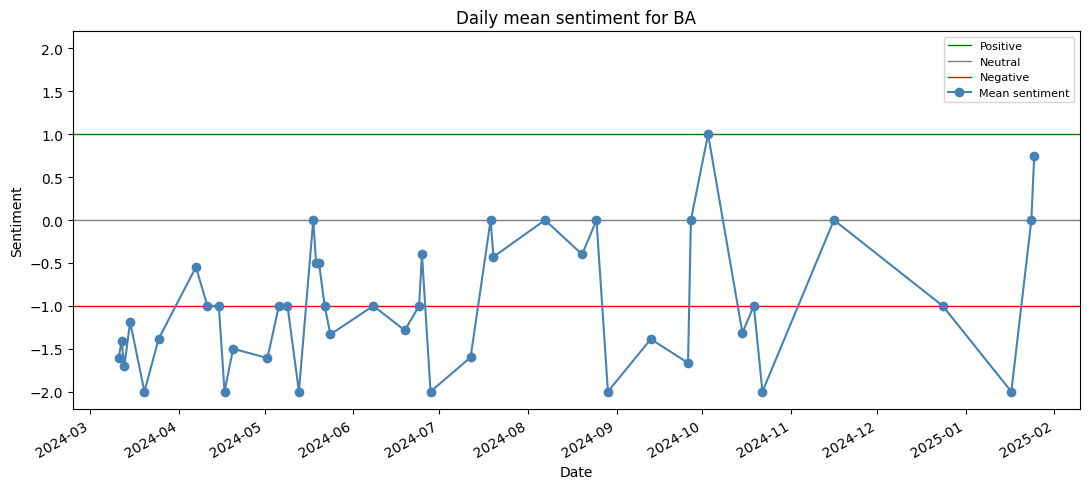

In [57]:
def plot_ticker_sentiment(ticker: str):
    data = daily[daily["ticker"] == ticker].sort_values("date")

    fig, ax = plt.subplots(figsize=(11, 5))

    # Reference lines for the sentiment scale
    ax.axhline(1, color="green", linewidth=1, label="Positive")
    ax.axhline(0, color="gray", linewidth=1, label="Neutral")
    ax.axhline(-1, color="red", linewidth=1, label="Negative")

    # Daily mean sentiment trend
    ax.plot(data["date"], data["mean_sentiment"], marker="o", color="steelblue", label="Mean sentiment")

    ax.set_title(f"Daily mean sentiment for {ticker}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Sentiment")
    ax.set_ylim(-2.2, 2.2)
    ax.legend(loc="upper right", fontsize=8)
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()

plot_ticker_sentiment("BA")

## Comparing sentiment with stock price

A natural question is whether the Reddit sentiment relates to the company's stock price. 
We fetch daily closing prices for the richest tickers (BA, AMZN, TSLA, GOOGL, META) over 
the same period as the comments. Because the Leonardo compute nodes have no internet 
access, the prices were downloaded separately on a local machine and brought in as a CSV, 
the same pattern used for the ticker list.

Two cautions guide the interpretation. First, the sentiment in this dataset reflects 
general public opinion (much of it Boeing crisis coverage) rather than pure market 
analysis, so any relationship should be read as a hypothesis, not a causal claim. We look 
for whether sentiment dips appear to coincide with price moves, not whether one causes 
the other. Second, if sentiment carries any predictive value it should lead price rather 
than move with it. We therefore also look at lagged relationships, comparing sentiment 
against price a few days later, to see whether shifts in sentiment precede shifts in price.

In [58]:
ba_prices = pd.read_csv("../../hugo/BA_prices.csv")

# Clean: strip "$" from price columns and parse to float
for col in ["Close/Last", "Open", "High", "Low"]:
    ba_prices[col] = ba_prices[col].str.replace("$", "", regex=False).astype(float)

# Parse the US-format date (MM/DD/YYYY) and keep only what we need
ba_prices["date"] = pd.to_datetime(ba_prices["Date"], format="%m/%d/%Y").dt.date
ba_prices = ba_prices[["date", "Close/Last"]].rename(columns={"Close/Last": "price"})

# Filter to the comment period
ba_prices = ba_prices[(ba_prices["date"] >= pd.to_datetime("2024-03-01").date()) &
                      (ba_prices["date"] <= pd.to_datetime("2025-02-15").date())]

ba_prices = ba_prices.sort_values("date")
print(f"{len(ba_prices)} trading days")
ba_prices.head()

241 trading days


,date,price
574,2024-03-01,200.00
573,2024-03-04,200.54
572,2024-03-05,201.14
571,2024-03-06,201.00
570,2024-03-07,203.03


In [59]:
# BA sentiment, daily
ba_sentiment = daily[daily["ticker"] == "BA"][["date", "mean_sentiment", "n_comments"]].copy()

# Merge sentiment with price on date. Outer join keeps all trading days for the price line,
# even days with no comments
ba = pd.merge(ba_prices, ba_sentiment, on="date", how="left").sort_values("date")

print(f"{len(ba)} rows, of which {ba['mean_sentiment'].notna().sum()} have sentiment")
ba.head()

241 rows, of which 33 have sentiment


,date,price,mean_sentiment,n_comments
0,2024-03-01,200.00,NaN,NaN
1,2024-03-04,200.54,NaN,NaN
2,2024-03-05,201.14,NaN,NaN
3,2024-03-06,201.00,NaN,NaN
4,2024-03-07,203.03,NaN,NaN


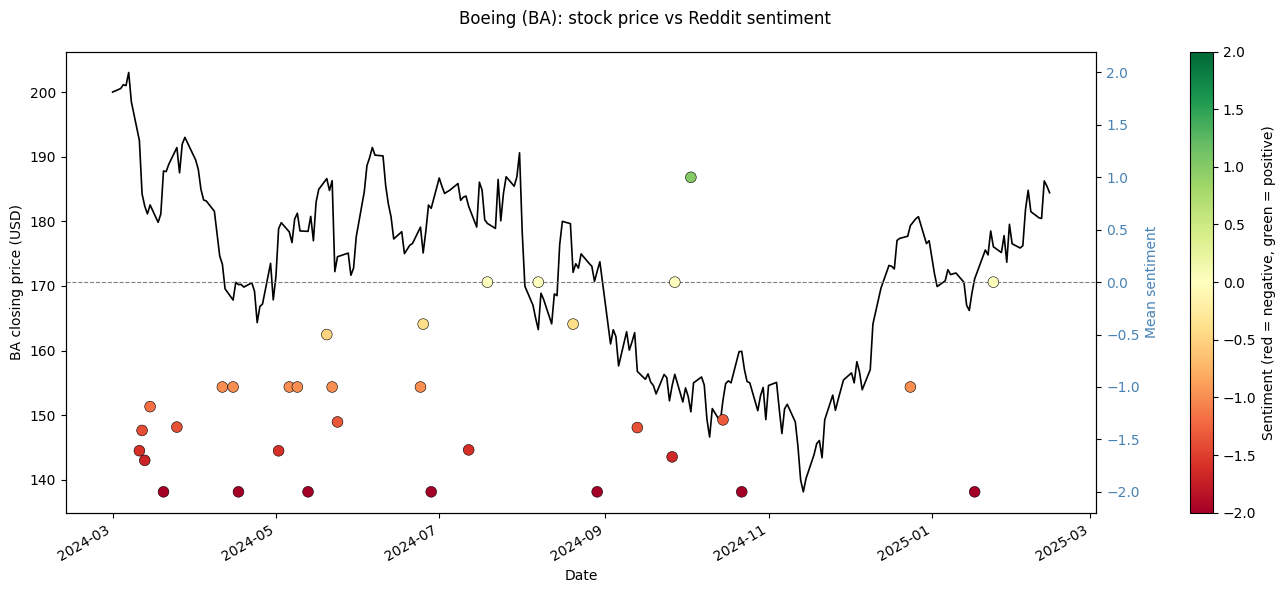

In [60]:
fig, ax1 = plt.subplots(figsize=(13, 6))

# Left axis: stock price
ax1.plot(ba["date"], ba["price"], color="black", linewidth=1.2, label="BA price")
ax1.set_xlabel("Date")
ax1.set_ylabel("BA closing price (USD)", color="black")
ax1.tick_params(axis="y", labelcolor="black")

# Right axis: sentiment, colour-coded from red (negative) to green (positive)
ax2 = ax1.twinx()
sent = ba.dropna(subset=["mean_sentiment"])
sc = ax2.scatter(sent["date"], sent["mean_sentiment"],
                 c=sent["mean_sentiment"], cmap="RdYlGn",
                 vmin=-2, vmax=2, s=60, edgecolor="black", linewidth=0.4, zorder=5)
ax2.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax2.set_ylabel("Mean sentiment", color="steelblue")
ax2.tick_params(axis="y", labelcolor="steelblue")
ax2.set_ylim(-2.2, 2.2)

# Colour bar to explain the sentiment scale
cbar = fig.colorbar(sc, ax=ax2, pad=0.08, fraction=0.04)
cbar.set_label("Sentiment (red = negative, green = positive)")

fig.suptitle("Boeing (BA): stock price vs Reddit sentiment")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [61]:
# Work on the merged daily frame, sorted by date
ba_corr = ba.sort_values("date").copy()

# Daily price change (return) in percent
ba_corr["price_return"] = ba_corr["price"].pct_change() * 100

# Correlate sentiment with price return at several lags.
# lag = 0  : same-day return
# lag = +k : return k trading days AFTER the sentiment (does sentiment lead price?)
for lag in [0, 1, 2, 3, 5]:
    shifted_return = ba_corr["price_return"].shift(-lag)
    pair = pd.DataFrame({
        "sentiment": ba_corr["mean_sentiment"],
        "future_return": shifted_return,
    }).dropna()
    corr = pair["sentiment"].corr(pair["future_return"])
    print(f"lag {lag} days: corr(sentiment, return) = {corr:+.3f}   (n = {len(pair)})")

lag 0 days: corr(sentiment, return) = -0.277   (n = 33)
lag 1 days: corr(sentiment, return) = +0.076   (n = 33)
lag 2 days: corr(sentiment, return) = +0.422   (n = 33)
lag 3 days: corr(sentiment, return) = -0.429   (n = 33)
lag 5 days: corr(sentiment, return) = -0.035   (n = 33)


## Running the full dataset

The analysis so far used the company subset (comments pre-filtered to mention known 
companies). That was useful for development and for the subset comparison, but it has two 
limitations: it only captures the companies we searched for, and it gives relatively few 
data points per ticker, which makes the sentiment-price correlation unreliable (the Boeing 
analysis rested on just 33 paired days).

We now run the full pipeline on all ~102k comments. This matters for two reasons. First, 
it removes the pre-filtering bias: any company mentioned in any comment can be picked up, 
not only the ten we seeded the keyword search with. Second, it increases the number of 
daily sentiment points per ticker, which gives the correlation analysis more to work with. 
Parallelisation makes this feasible: what would take many hours sequentially runs in 
minutes with a thread pool.

We save the result to disk immediately after the run, so that this expensive computation 
survives a kernel restart and does not need to be repeated.

In [62]:
def run_in_batches(comments_df, out_path, batch_size=5000, max_workers=16):
    # Resume support: if the file already exists, skip batches already done
    start_batch = 0
    if os.path.exists(out_path):
        done = pd.read_csv(out_path)
        start_batch = int(done["source_index"].max()) // batch_size + 1
        print(f"Resuming from batch {start_batch} ({len(done)} rows already saved)")

    def handle(idx, rec):
        out = []
        for row in process_comment(rec["comments"]):
            row["datetime"] = rec["datetime"]
            row["source_index"] = idx
            out.append(row)
        return out

    n = len(comments_df)
    total_batches = (n // batch_size) + 1

    for b in range(start_batch, total_batches):
        chunk = comments_df.iloc[b * batch_size : (b + 1) * batch_size]
        if len(chunk) == 0:
            break

        start = time.time()
        rows = []
        with ThreadPoolExecutor(max_workers=max_workers) as ex:
            futures = [ex.submit(handle, idx, rec)
                       for idx, rec in zip(chunk.index, chunk.to_dict("records"))]
            for f in as_completed(futures):
                rows.extend(f.result())

        batch_df = pd.DataFrame(rows)
        header = not os.path.exists(out_path)
        batch_df.to_csv(out_path, mode="a", header=header, index=False)
        print(f"Batch {b+1}/{total_batches}: {len(chunk)} comments -> "
              f"{len(batch_df)} rows in {time.time()-start:.0f}s (saved)")

In [63]:
run_in_batches(df.sample(50000, random_state=42), "../../hugo/all_results.csv", batch_size=5000, max_workers=16)

Resuming from batch 21 (1015 rows already saved)


## Designing a SLURM agent

The final task is to design an agent that lets a non-technical user run the pipeline on 
Leonardo using natural language. The boss cannot write or execute code. He only wants to 
send prompts in plain English such as "run tonight's analysis" or "is the job done yet?". 
The agent translates these into SLURM commands.

An agent here has three parts. An LLM that interprets the user's request, a set of tools 
(functions the agent can call), and a system prompt that tells the LLM its role and when 
to use each tool. The user speaks naturally, the LLM decides which tool to call, and the 
tool runs the actual SLURM command.

### Tools

The agent has four tools, one per SLURM operation the user needs:

- **submit_job**: launches the analysis on Leonardo by running `sbatch` on the job script. 
  This is the core action, triggered by a prompt like "run tonight's analysis".
- **check_status**: reports on running and pending jobs using `squeue`, so the user can ask 
  "is the job done yet?" and get a readable answer.
- **cancel_job**: stops a job with `scancel`, for when the user wants to abort a run.
- **get_results**: reads the saved output (the results CSV or the job's output file) and 
  summarises it, so the user can ask "show me the results" once a job has finished.

Together these cover the full workflow a non-technical user needs, start, monitor, cancel 
and retrieve. One design consideration is safety cancel_job has a real and irreversible 
side effect, so the agent should confirm with the user before cancelling, rather than 
acting on a possibly misinterpreted prompt. The same caution applies to submit_job, to 
avoid launching duplicate expensive jobs.

In [64]:
def submit_job(job_script: str = "../../hugo/student_job_LLM.job") -> str:
    """Launch the analysis pipeline on Leonardo with sbatch."""
    result = subprocess.run(
        ["sbatch", job_script],
        capture_output=True, text=True
    )
    if result.returncode == 0:
        return f"Job submitted successfully. {result.stdout.strip()}"
    return f"Failed to submit job: {result.stderr.strip()}"

def check_status() -> str:
    """Check the status of the user's SLURM jobs with squeue."""
    result = subprocess.run(["squeue", "--me"], capture_output=True, text=True)
    if result.returncode == 0:
        output = result.stdout.strip()
        return output if output else "No jobs found in the queue."
    return f"Failed to check status: {result.stderr.strip()}"

def cancel_job(job_id: str) -> str:
    """Cancel a specific SLURM job by its ID with scancel."""
    result = subprocess.run(["scancel", job_id], capture_output=True, text=True)
    if result.returncode == 0:
        return f"Job {job_id} cancelled."
    return f"Failed to cancel job {job_id}: {result.stderr.strip()}"

def get_results(results_path: str = "../../hugo/all_results.csv") -> str:
    """Read the saved results CSV and return a short summary."""
    if not os.path.exists(results_path):
        return "No results file found yet. The job may not have finished."
    df_res = pd.read_csv(results_path)
    return (f"Results contain {len(df_res)} ticker rows across "
            f"{df_res['ticker'].nunique()} tickers. "
            f"Most mentioned: {df_res['ticker'].value_counts().head(5).to_dict()}")

### System prompt

The system prompt is what turns a general LLM into a SLURM operator. It must state the 
model's role, describe the tools available, and instruct it to respond with a structured 
tool call rather than prose. We use structured output, the same pattern as in the 
extraction and sentiment steps. The model returns which tool to call and with what 
arguments, and our code executes it. This keeps the agent predictable and avoids the model 
hallucinating shell commands directly.

In [65]:
class ToolName(str, Enum):
    SUBMIT_JOB = "submit_job"
    CHECK_STATUS = "check_status"
    CANCEL_JOB = "cancel_job"
    GET_RESULTS = "get_results"
    NONE = "none"

class AgentAction(BaseModel):
    tool: ToolName
    job_id: Optional[str] = None      # only needed for cancel_job
    reply_to_user: str                # a plain-English message for the boss

AGENT_SYSTEM_PROMPT = """You are an assistant that helps a non-technical user run a Reddit
sentiment-analysis pipeline on the Leonardo HPC cluster using SLURM. The user speaks in
plain English and cannot write code. Your job is to decide which tool to call.

Available tools:
- submit_job: launch the analysis pipeline (use for "run the analysis", "start tonight's run")
- check_status: check running and pending jobs (use for "is it done?", "what's running?")
- cancel_job: cancel a job, requires a job_id (use for "stop the job", "cancel run 12345")
- get_results: read and summarise the saved results (use for "show me the results")
- none: no tool needed, just reply (use for greetings or questions you can answer directly)

Rules:
- For cancel_job you must provide the job_id. If the user did not give one, call
  check_status first and ask them to confirm which job to cancel.
- Always set reply_to_user to a short, friendly message in plain English explaining what
  you are doing, with no technical jargon.
- Never invent job IDs or results."""

In [66]:
# Map tool names to the actual functions
TOOLS = {
    ToolName.SUBMIT_JOB: lambda action: submit_job(),
    ToolName.CHECK_STATUS: lambda action: check_status(),
    ToolName.CANCEL_JOB: lambda action: cancel_job(action.job_id),
    ToolName.GET_RESULTS: lambda action: get_results(),
    ToolName.NONE: lambda action: "",
}

def run_agent(user_message: str) -> str:
    # Ask the LLM which tool to call, using structured output
    action = llm.with_structured_output(AgentAction).invoke(
        input=[
            {"role": "system", "content": AGENT_SYSTEM_PROMPT},
            {"role": "user", "content": user_message},
        ],
        temperature=0,
    )

    # Run the chosen tool (if any)
    tool_output = TOOLS[action.tool](action)

    # Build the reply for the user
    if action.tool == ToolName.NONE:
        return action.reply_to_user
    return f"{action.reply_to_user}\n\n[Tool: {action.tool.value}]\n{tool_output}"

In [67]:
# Ready to run once the model server is up
for msg in ["Is the analysis done yet?",
            "Show me the results so far",
            "Run tonight's analysis",
            "Hello, what can you do?"]:
    print(f"USER: {msg}")
    print(run_agent(msg))
    print("-" * 60)

USER: Is the analysis done yet?
Let me check the status of your analysis for you.

[Tool: check_status]
JOBID PARTITION     NAME     USER ST       TIME  NODES NODELIST(REASON)
          47197521 boost_usr llm_laun hdahlqui  R    4:26:10      1 lrdn2874
          47197520 boost_usr jupyter_ hdahlqui  R    6:02:43      1 lrdn0022
------------------------------------------------------------
USER: Show me the results so far
Sure, I'll show you the results so far.

[Tool: get_results]
Results contain 1015 ticker rows across 159 tickers. Most mentioned: {'TSLA': 120, 'BA': 91, 'META': 61, 'AMZN': 48, 'MCD': 42}
------------------------------------------------------------
USER: Run tonight's analysis
Starting tonight's analysis. I'll let you know when it's done!

[Tool: submit_job]
Job submitted successfully. Submitted batch job 47227423
------------------------------------------------------------
USER: Hello, what can you do?
Hello! I can help you run a Reddit sentiment-analysis pipeline on 

In [68]:
print(run_agent("Is the analysis done yet?"))

Let me check the status of your analysis for you.

[Tool: check_status]
JOBID PARTITION     NAME     USER ST       TIME  NODES NODELIST(REASON)
          47197521 boost_usr llm_laun hdahlqui  R    4:27:08      1 lrdn2874
          47197520 boost_usr jupyter_ hdahlqui  R    6:03:41      1 lrdn0022


In [69]:
print(run_agent("Show me the results so far"))

Sure, I'll show you the results so far.

[Tool: get_results]
Results contain 1015 ticker rows across 159 tickers. Most mentioned: {'TSLA': 120, 'BA': 91, 'META': 61, 'AMZN': 48, 'MCD': 42}


In [70]:
print(run_agent("Hello, what can you do?"))

Hello! I can help you run a Reddit sentiment-analysis pipeline on the Leonardo HPC cluster. Just let me know what you need, like starting a run, checking its status, or seeing the results.


In [71]:
print(run_agent("Run tonight's analysis"))

Starting tonight's analysis. I'll let you know when it's done!

[Tool: submit_job]
Job submitted successfully. Submitted batch job 47227530


In [72]:
pd.read_csv("../../hugo/nightly_results.csv")

,ticker,sentiment,score,datetime
0,UNH,Very Negative,-2,2025-01-17 00:31:52
1,TSLA,Very Negative,-2,2024-10-31 14:29:43
2,COIN,Negative,-1,2024-08-19 23:10:55
3,BA,Very Negative,-2,2024-10-15 14:29:47
